In [2]:
from rftrack.aux import plot_phase_space
from rftrack.data import parser
import RF_Track as rft
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde

def plot_phase_space_4panel(
    x, xp, y, yp,
    filename="phase_space_4panel",
    save=True,
    units_already_mm_mrad=True,
    bw_method=0.5,
    point_size=5,
    alpha=0.85,
    cmap="viridis",
    label_fontsize=16,
    tick_fontsize=13,
    cbar_fontsize=13,
    figsize=(13, 10)
):
    """
    Plotea en una figura 2x2:

        x  - x'
        y  - y'
        x  - y
        x' - y'

    Guarda el PDF en la carpeta actual.
    """

    x = np.asarray(x)
    xp = np.asarray(xp)
    y = np.asarray(y)
    yp = np.asarray(yp)

    if not units_already_mm_mrad:
        x = x * 1e3
        y = y * 1e3
        xp = xp * 1e3
        yp = yp * 1e3

    def density_scatter(ax, a, b, xlabel, ylabel):
        a = np.asarray(a)
        b = np.asarray(b)

        mask = np.isfinite(a) & np.isfinite(b)
        a = a[mask]
        b = b[mask]

        xy = np.vstack([a, b])

        try:
            kde = gaussian_kde(xy, bw_method=bw_method)
            z = kde(xy)

            idx = z.argsort()
            a = a[idx]
            b = b[idx]
            z = z[idx]

            sc = ax.scatter(
                a, b,
                c=z,
                s=point_size,
                cmap=cmap,
                alpha=alpha,
                edgecolors="none"
            )

            cbar = plt.colorbar(sc, ax=ax)
            cbar.set_label("Densidad de partículas", fontsize=cbar_fontsize)
            cbar.ax.tick_params(labelsize=tick_fontsize)

        except Exception:
            ax.scatter(
                a, b,
                s=point_size,
                alpha=alpha,
                edgecolors="none"
            )

        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.grid(True, alpha=0.3)

    fig, axs = plt.subplots(2, 2, figsize=figsize)

    density_scatter(axs[0, 0], x, xp, r"$x$ [mm]", r"$x'$ [mrad]")
    density_scatter(axs[0, 1], y, yp, r"$y$ [mm]", r"$y'$ [mrad]")
    density_scatter(axs[1, 0], x, y, r"$x$ [mm]", r"$y$ [mm]")
    density_scatter(axs[1, 1], xp, yp, r"$x'$ [mrad]", r"$y'$ [mrad]")

    fig.tight_layout()

    if save:
        pdf_path = Path.cwd() / f"{filename}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Guardado en: {pdf_path}")

    plt.show()


[RF-Track] Could not check for updates.



RF-Track, version 2.5.6

Copyright (C) 2016-2026 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.5 and fftw-3.3.5-sse2-avx



N: 15673, Mass: 11174.9 MeV, Energy: 0.182629 MeV, Frequency: 749.48 MHz, Current: 0.0 A, Charge: 6 e
Guardado en: /home/guest/tfm_pedro/Validation-of-linear-ion-accelerator/phase_space_4panel.pdf


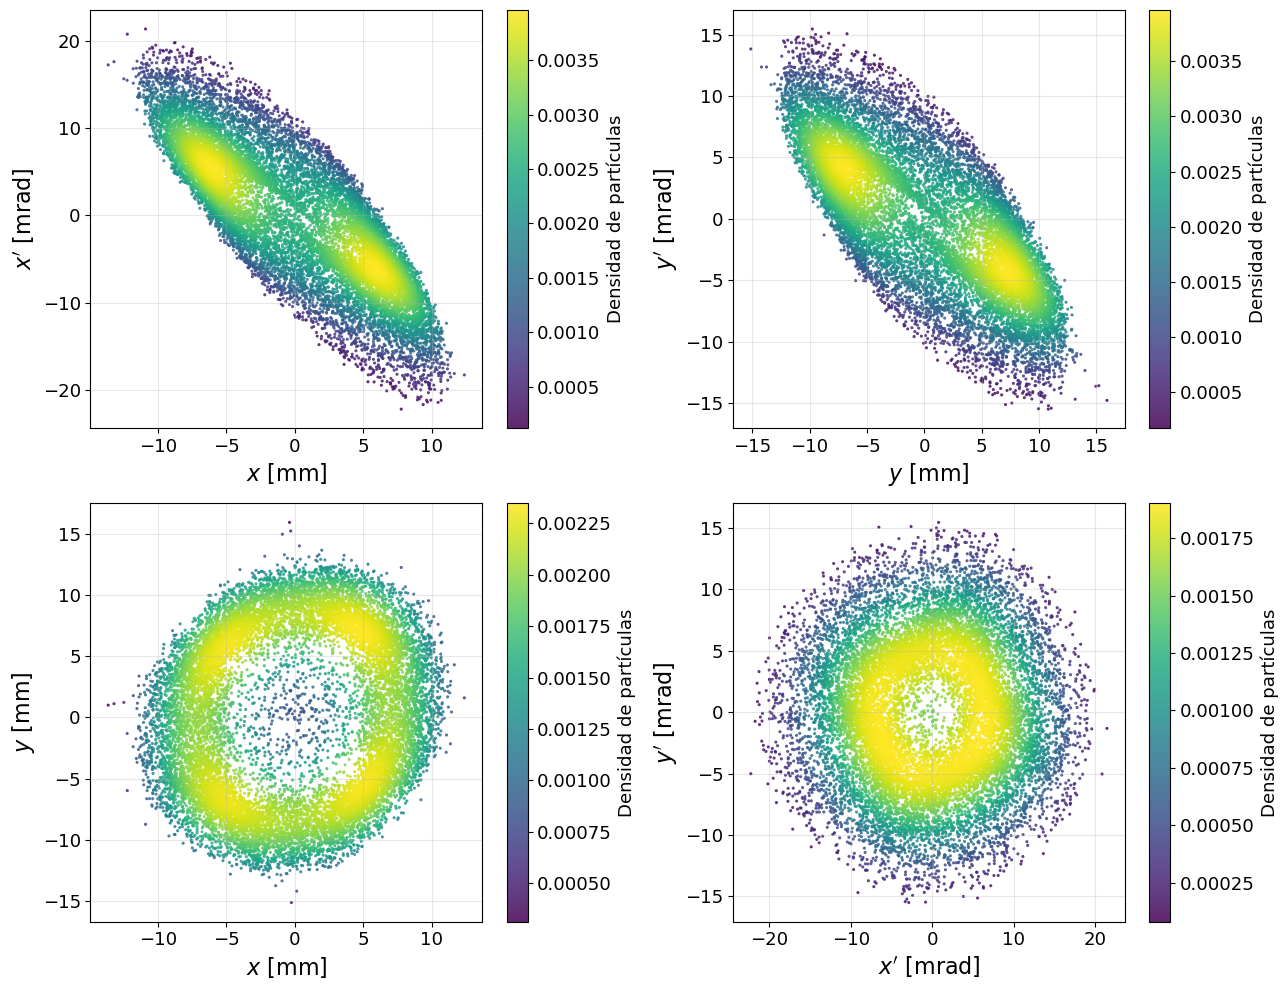

In [3]:
B0 = parser("inputs/beam_outDipole_12C6+.txt")
M0 = B0.get_phase_space('%x %xp %y %yp %N')

x  = M0[:,0]
xp = M0[:,1]
y  = M0[:,2]
yp = M0[:,3]
No = M0[:,4]


plot_phase_space_4panel(
    x=x,
    xp=xp,
    y=y,
    yp=yp,
    filename="phase_space_4panel",
)


2613


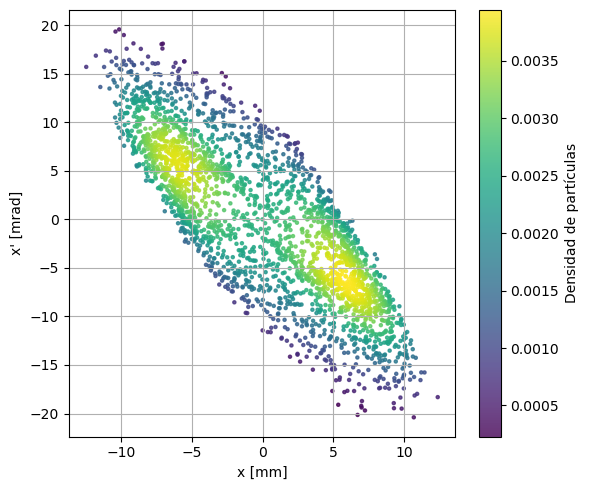

In [4]:
opal_in = np.loadtxt("opal/data/lebt_DISTRIB2.dat", skiprows=2)

x_opal  = opal_in[:, 0] * 1000
px_opal = opal_in[:, 1]
y_opal  = opal_in[:, 2] * 1000
py_opal = opal_in[:, 3]
pz_opal = opal_in[:, 5]
print(len(x_opal))

xp_opal = px_opal / pz_opal * 1000
yp_opal = py_opal / pz_opal * 1000

plot_phase_space(x_opal, xp_opal, "x [mm]", "x' [mrad]")

15673


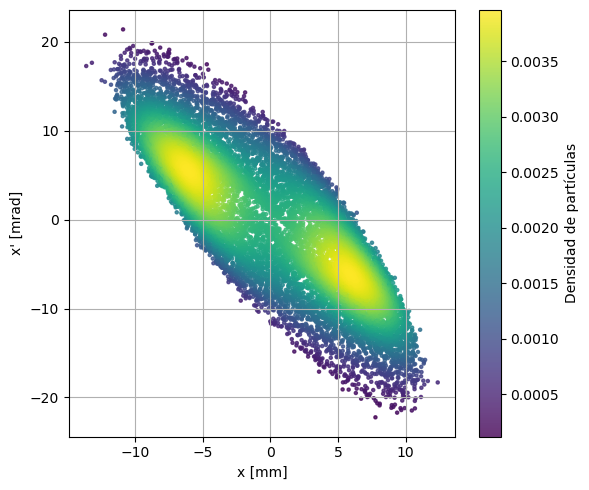

26.97233905609 -26.42739328031


In [5]:
opal_in = np.loadtxt("opal/opal_beam.txt", skiprows=1)

x_opal  = opal_in[:, 0] * 1e3
px_opal = opal_in[:, 1]
y_opal  = opal_in[:, 2] * 1e3
py_opal = opal_in[:, 3]
z_opal  = opal_in[:, 4] * 1e3
pz_opal = opal_in[:, 5]
print(len(x_opal))

xp_opal = px_opal / pz_opal * 1e3
yp_opal = py_opal / pz_opal * 1e3

plot_phase_space(x_opal, xp_opal, "x [mm]", "x' [mrad]")
print(max(z_opal), min(z_opal))


15673


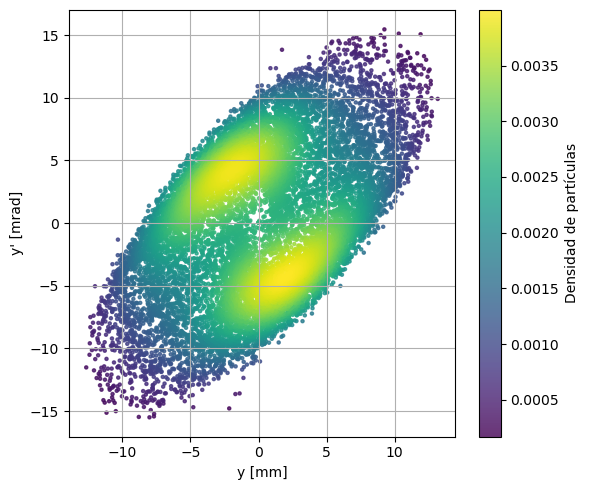

14896


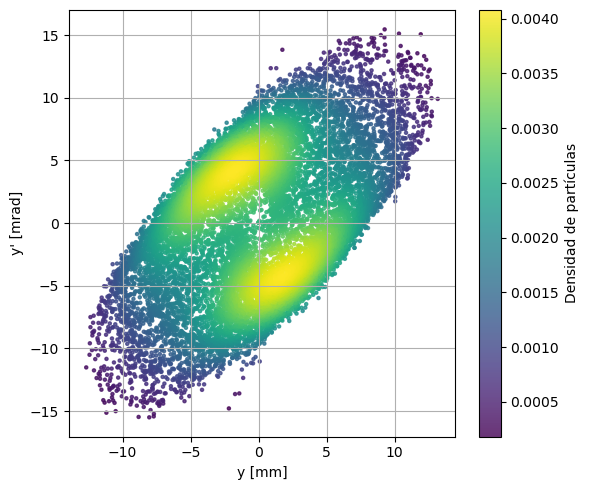

In [6]:
opal_in = np.loadtxt("opal/MONITOR_TEST1.loss", skiprows=1)

x_opal  = opal_in[:, 0] * 1e3
px_opal = opal_in[:, 3]
y_opal  = opal_in[:, 1] * 1e3
py_opal = opal_in[:, 4]
z_opal  = opal_in[:, 2] * 1e3
pz_opal = opal_in[:, 5]
print(len(x_opal))

xp_opal = px_opal / pz_opal * 1e3
yp_opal = py_opal / pz_opal * 1e3

plot_phase_space(y_opal, yp_opal, "y [mm]", "y' [mrad]")

opal_in = np.loadtxt("opal/MONITOR_TEST2.loss", skiprows=1)

x_opal  = opal_in[:, 0] * 1e3
px_opal = opal_in[:, 3]
y_opal  = opal_in[:, 1] * 1e3
py_opal = opal_in[:, 4]
z_opal  = opal_in[:, 2] * 1e3
pz_opal = opal_in[:, 5]
print(len(x_opal))

xp_opal = px_opal / pz_opal * 1e3
yp_opal = py_opal / pz_opal * 1e3

plot_phase_space(y_opal, yp_opal, "y [mm]", "y' [mrad]")